<a href="https://colab.research.google.com/github/sathaniya-m/Student-Performance-Analytics/blob/main/Studentperformances.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from google.colab import files
uploaded=files.upload()

Saving student.csv to student (1).csv


In [29]:
import pandas as pd
df=pd.read_csv('student.csv')
print(df.head())

  Student_name  Tamil  English  Java  Python  PHP  Data science
0    Sathaniya     90       88    77      96  100            88
1       Smitha     46       86    64      74   64            78
2        Priya     96       75    85      95   47            66
3     Manushri     67       74    57      78   57            86
4         Maha     79       85    86      58   89            74


In [31]:
subjects = ['Tamil','English','Java','Python','PHP','Data science']

df['Total_Marks'] = df[subjects].sum(axis=1)
df['Average'] = df[subjects].mean(axis=1)

print(df[['Student_name','Total_Marks','Average']])

  Student_name  Total_Marks    Average
0    Sathaniya          539  89.833333
1       Smitha          412  68.666667
2        Priya          464  77.333333
3     Manushri          419  69.833333
4         Maha          471  78.500000
5      Karthik          452  75.333333
6     Shenbaga          179  29.833333
7         Raju          260  43.333333
8        Kumar          161  26.833333
9        Shree          301  50.166667


In [32]:
def assign_grade(avg):
    if avg >= 90:
        return 'A+'
    elif avg >= 80:
        return 'A'
    elif avg >= 70:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(assign_grade)

df['Status'] = np.where(df['Average'] >= 50, 'Pass', 'Fail')

print(df[['Student_name','Average','Grade','Status']])

  Student_name    Average Grade Status
0    Sathaniya  89.833333     A   Pass
1       Smitha  68.666667     C   Pass
2        Priya  77.333333     B   Pass
3     Manushri  69.833333     C   Pass
4         Maha  78.500000     B   Pass
5      Karthik  75.333333     B   Pass
6     Shenbaga  29.833333     F   Fail
7         Raju  43.333333     F   Fail
8        Kumar  26.833333     F   Fail
9        Shree  50.166667     D   Pass


In [33]:
topper = df.loc[df['Average'].idxmax()]

print("Top Performer")
print("Name:", topper['Student_name'])
print("Average:", topper['Average'])
print("Grade:", topper['Grade'])

Top Performer
Name: Sathaniya
Average: 89.83333333333333
Grade: A


In [34]:
weak_students = df[df['Status'] == 'Fail']

print("Weak Students")
print(weak_students[['Student_name','Average']])

Weak Students
  Student_name    Average
6     Shenbaga  29.833333
7         Raju  43.333333
8        Kumar  26.833333


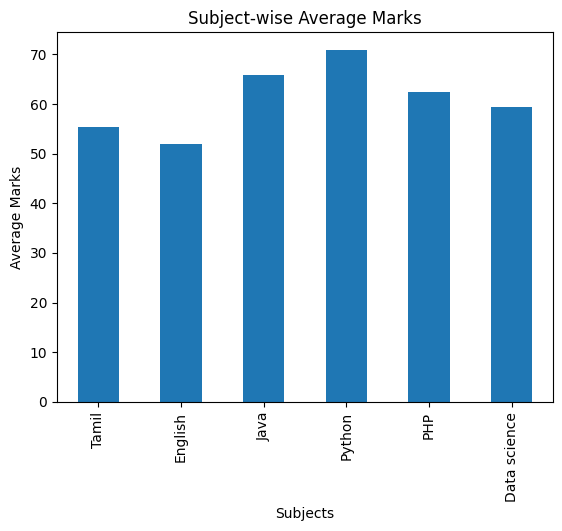

In [36]:
subject_avg = df[['Tamil','English','Java','Python','PHP','Data science']].mean()

subject_avg.plot(kind='bar')

plt.title("Subject-wise Average Marks")
plt.xlabel("Subjects")
plt.ylabel("Average Marks")
plt.show()

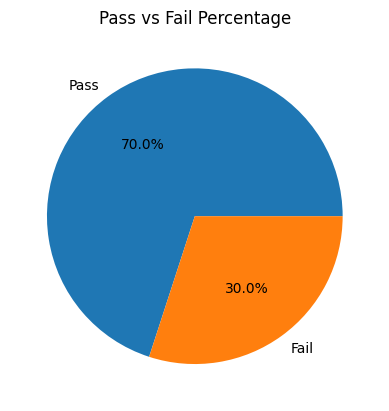

In [37]:
status_count = df['Status'].value_counts()

plt.pie(status_count,
        labels=status_count.index,
        autopct='%1.1f%%')

plt.title("Pass vs Fail Percentage")
plt.show()

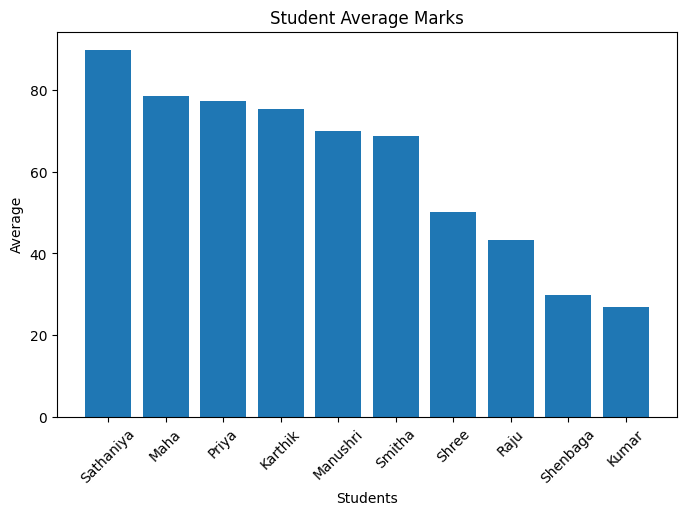

In [38]:
top_students = df.sort_values(by='Average', ascending=False)

plt.figure(figsize=(8,5))
plt.bar(top_students['Student_name'],
        top_students['Average'])

plt.title("Student Average Marks")
plt.xlabel("Students")
plt.ylabel("Average")
plt.xticks(rotation=45)

plt.show()

In [39]:
print("Highest Performing Subject:",
      subject_avg.idxmax())

print("Lowest Performing Subject:",
      subject_avg.idxmin())

print("Pass Percentage:",
      round((df['Status']=='Pass').mean()*100,2),"%")

print("Class Average:",
      round(df['Average'].mean(),2))

Highest Performing Subject: Python
Lowest Performing Subject: English
Pass Percentage: 70.0 %
Class Average: 60.97


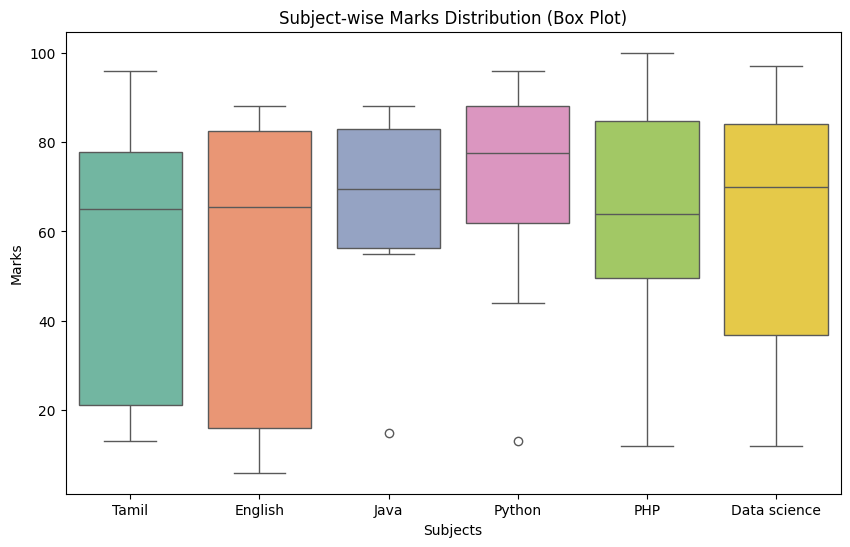

In [41]:
# 3. Box Plot for Subject Marks Distribution
plt.figure(figsize=(10, 6))

# Melting or selecting data so seaborn can plot multiple columns easily
sns.boxplot(data=df[['Tamil', 'English', 'Java', 'Python', 'PHP','Data science']], palette='Set2')

plt.title('Subject-wise Marks Distribution (Box Plot)')
plt.xlabel('Subjects')
plt.ylabel('Marks')
plt.show()

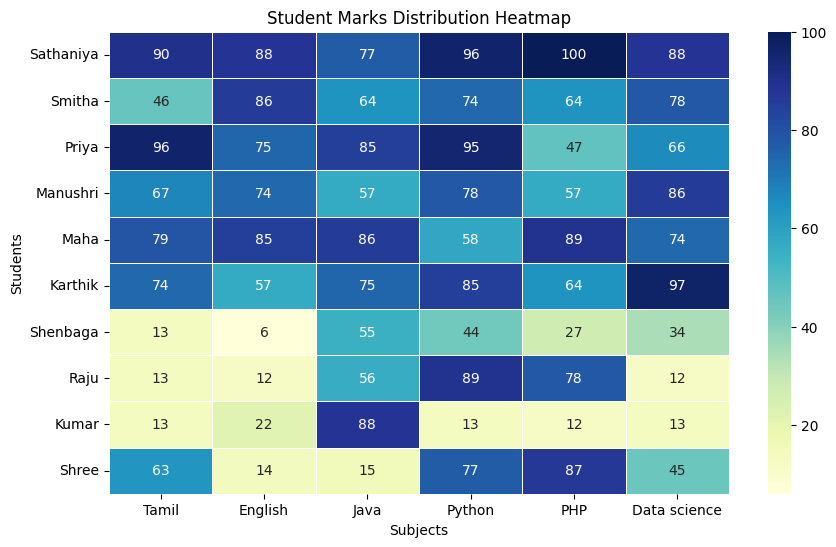

In [44]:
# 2. Student Marks Heatmap
plt.figure(figsize=(10, 6))

# Setting Student_name as the index so it shows on the y-axis
marks_heatmap_df = df.set_index('Student_name')[['Tamil', 'English', 'Java', 'Python','PHP','Data science']]

# Generating the heatmap
sns.heatmap(marks_heatmap_df, annot=True, cmap='YlGnBu', fmt="g", linewidths=0.5)

plt.title('Student Marks Distribution Heatmap')
plt.ylabel('Students')
plt.xlabel('Subjects')
plt.show()

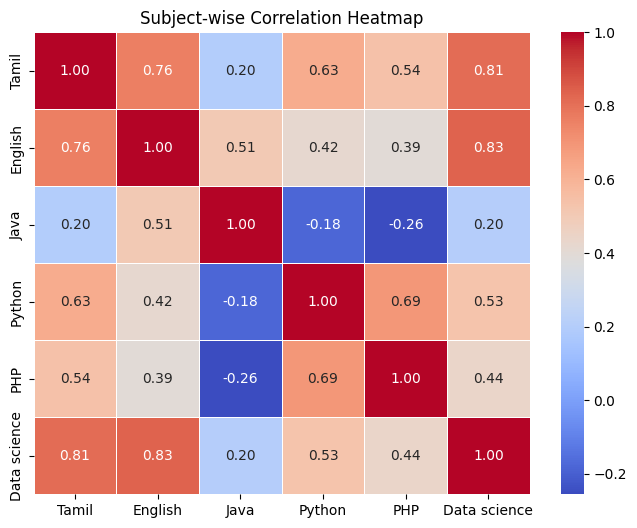

In [46]:
# 1. Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

# Subsetting only the subject marks columns for correlation
subjects_df = df[['Tamil', 'English','Java','Python','PHP','Data science']]
correlation_matrix = subjects_df.corr()

# Generating the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Subject-wise Correlation Heatmap')
plt.show()